<a href="https://colab.research.google.com/github/isha3456/Isha-/blob/main/MegaProject(01).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Waste_ID        Material        Color  Weight_kg  Moisture_% Biodegradable  \
0    W0001       Metal Can       Silver       4.09          61            No   
1    W0002  Plastic Bottle  Transparent       3.43          84            No   
2    W0003       Newspaper        White       2.74          83            No   
3    W0004       Metal Can       Silver       1.83          68            No   
4    W0005         Battery        Black       4.76          17            No   

  Recyclable Hazardous   Category  
0        Yes        No        Dry  
1        Yes        No        Dry  
2        Yes        No        Dry  
3        Yes        No        Dry  
4         No       Yes  Hazardous  
    Waste_ID        Material        Color  Weight_kg  Moisture_%  \
995    W0996          Leaves        Green       3.10          61   
996    W0997  Plastic Bottle  Transparent       3.63          58   
997    W0998    Glass Bottle        Green       1.35          86   
998    W0999          Leaves   

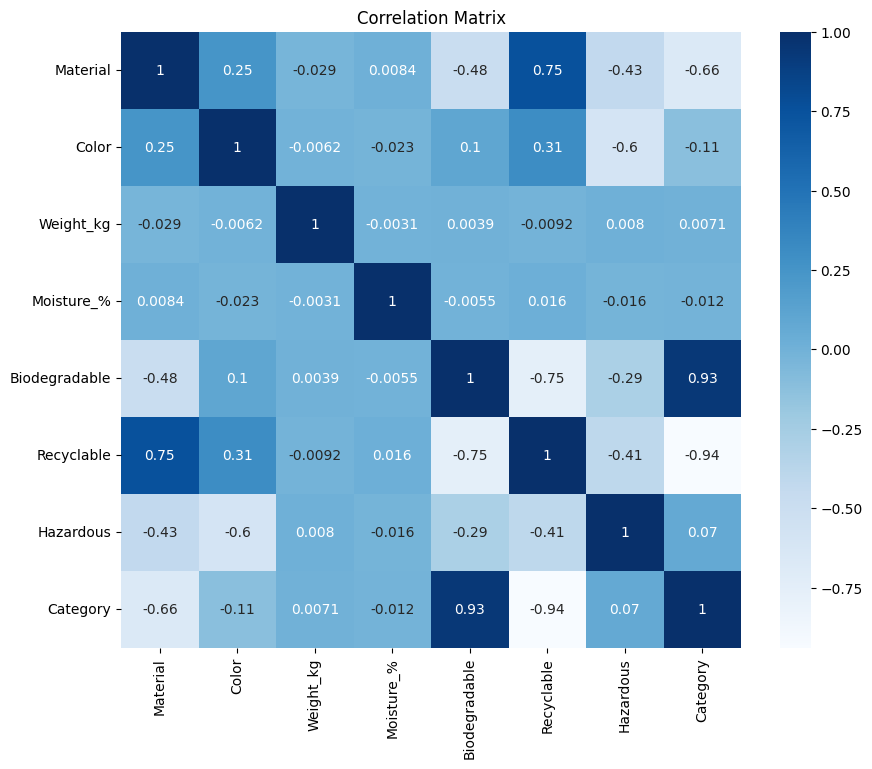

Logistic Regression Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00        30
           2       1.00      1.00      1.00        70

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


Confusion Matrix
[[100   0   0]
 [  0  30   0]
 [  0   0  70]]
Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00        30
           2       1.00      1.00      1.00        70

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


Confusion Matrix
[[100   0   0]
 [  0  30   0]
 [  0   0  70]]
Random Forest Accuracy: 1.0
              precis

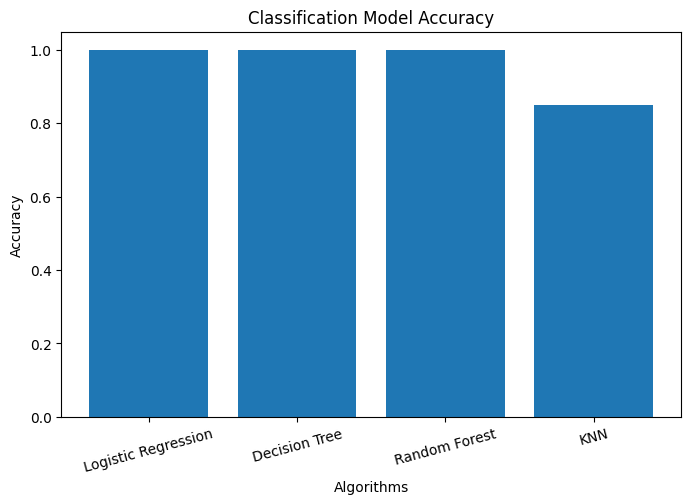

In [4]:
#import required Lybraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Read CSV File
df = pd.read_csv("GWS.csv")

print (df.head())
print (df.tail())
print ("Rows and columns",df.shape)
print (df.info())
print (df.describe())
print (df.isnull().sum())
print("Duplicate Rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)


for column in df.columns:
    print(column)
    print(df[column].unique())
    print("----------------------")

le = LabelEncoder()

categorical_columns = [
    "Material",
    "Color",
    "Biodegradable",
    "Recyclable",
    "Hazardous",
    "Category"
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

    print(df.head())

df_corr = df.drop("Waste_ID", axis=1) # Drop 'Waste_ID' before calculating correlation

plt.figure(figsize=(10,8))
sns.heatmap(df_corr.corr(), annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

df.to_csv("Processed_Garbage_Dataset.csv", index=False)

X = df.drop(["Waste_ID", "Category"], axis=1)

y = df["Category"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("K-Nearest Neighbors Accuracy:", accuracy_knn)

print(classification_report(y_test, y_pred_knn))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_knn))

accuracy = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "KNN": accuracy_score(y_test, y_pred_knn)
}

comparison = pd.DataFrame(
    accuracy.items(),
    columns=["Algorithm", "Accuracy"]
)

print(comparison)

plt.figure(figsize=(8,5))

plt.bar(comparison["Algorithm"], comparison["Accuracy"])

plt.title("Classification Model Accuracy")

plt.xlabel("Algorithms")

plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.show()